## Tarea 1 - Matemáticas Aplicadas para Ciencia de Datos - Estadística Descriptiva y Análisis Exploratorio

**Objetivo:** Repasar conceptos básico de estadística descriptiva y aplicarlos en un conjunto de datos de precios de casas. Esta actividad es de **diagnóstico**, y no se calificará con una rúbrica estricta, pero sí se espera un esfuerzo serio en la entrega.. Servirá para conocer tu nivel actual de conceptos estadísticos y de exploración de datos. 


In [1]:
#Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [8]:
#Explrtamos el dataframe con pandas y verificamos que cargue de manera correcta
df_house_prices = pd.read_csv("https://raw.githubusercontent.com/ywchiu/riii/refs/heads/master/data/house-prices.csv")
df_house_prices.head(10)

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
5,6,114600,1780,3,2,2,No,North
6,7,151600,1830,3,3,3,Yes,West
7,8,150700,2160,4,2,2,No,West
8,9,119200,2110,4,2,3,No,East
9,10,104000,1730,3,3,3,No,East


In [5]:
#Extraemos la informacion del data frame
df_house_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


Con esto ultimo podemos destacar las siguientes cosas, el dataframe consiste de 128 entradas, de las cuales estan repartidas en8 categorias y todas ellas estan llenas, osease no tienen valores nullos.

## Clasificacion de variables mediante tipo cuantitativo o cualitativo

In [10]:
#Reciclamos el codigo de mi tarea de ML para obtener la clasificacion de variables
num_vars = df_house_prices.select_dtypes(include=[np.number]).columns
cat_vars = df_house_prices.select_dtypes(exclude=[np.number]).columns

print(f"Variables cuantitativas: {list(num_vars)}")
print(f"Variables cualitativas: {list(cat_vars)}")

Variables cuantitativas: ['Home', 'Price', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers']
Variables cualitativas: ['Brick', 'Neighborhood']


## Clasificación automática de niveles de medición

In [12]:
#creamos una funcion que separe y almacene los valores de cada categoria segun unos parametros
def clasificar_nivel_medicion(columna):
    if df_house_prices[columna].dtype == 'object':
        return 'Nominal'
    else:
        # Verificar si tiene cero absoluto (razón)
        if df_house_prices[columna].min() >= 0 and any(df_house_prices[columna] == 0):
            return 'Razón'
        else:
            return 'Intervalo'
#creamos un diccionario para guardarlos en pares
niveles = {}
for col in df_house_prices.columns:
    niveles[col] = clasificar_nivel_medicion(col)
    
print("Niveles de medición:")
for col, nivel in niveles.items():
    print(f"{col}: {nivel}")

Niveles de medición:
Home: Intervalo
Price: Intervalo
SqFt: Intervalo
Bedrooms: Intervalo
Bathrooms: Intervalo
Offers: Intervalo
Brick: Nominal
Neighborhood: Nominal


Por lo general cuando se tratan de bases donde se busca una relacion entre 2 datos el segundo dato es la variable dependiente, y como en este df lo que se busca es la relacionen entre la caracteristicas de la casa y su precio podemos asumir que **"Precio" es la variable dependiente**.

## Medidas de tendencia central

In [22]:
#Podemos obtener la media, mediana y moda con numpy o pandas, en este caso usare la columna precio
price_mean = df_house_prices['Price'].mean()
price_median = df_house_prices['Price'].median()
price_mode = df_house_prices['Price'].mode()

print(f"La media del precio es: {price_mean} \nLa mediana del precio es: {price_median}")
# Si hay múltiples modas, podemos mostrarlas todas
if len(price_mode) > 1:
    print(f"Hay {len(price_mode)} valores modales:")
    for i, valor in enumerate(price_mode, 1):
        print(f"Las Modas son {i}: {valor}")
else:
    print(f"La media del precio es: {price_mean} \n La mediana del precio es: {price_median} \nLa moda del precio es: {price_mode.iloc[0]}")

La media del precio es: 130427.34375 
La mediana del precio es: 125950.0
Hay 5 valores modales:
Las Modas son 1: 103200
Las Modas son 2: 105600
Las Modas son 3: 117800
Las Modas son 4: 125700
Las Modas son 5: 129800


### Medidas de dispersion

In [25]:
#Utilizamos pandas para sacar las medidas de dispersion solicitadas
resumen = df_house_prices['Price'].describe().T
resumen['Varianza'] = df_house_prices['Price'].var()
resumen['Q1'] = df_house_prices['Price'].quantile(0.25)
resumen['Q3'] = df_house_prices['Price'].quantile(0.75)
resumen[['mean', '50%', 'min', 'max', 'Varianza', 'std', 'Q1', 'Q3']]

mean        1.304273e+05
50%         1.259500e+05
min         6.910000e+04
max         2.112000e+05
Varianza    7.219308e+08
std         2.686877e+04
Q1          1.113250e+05
Q3          1.482500e+05
Name: Price, dtype: float64

### Tablas de frecuencia

In [27]:
#Tablas de frecuencia para Neighborhood y Brick
print("Tabla de frecuencia para Neighborhood:")
print(df_house_prices['Neighborhood'].value_counts())

print("\nTabla de frecuencia para Brick:")
print(df_house_prices['Brick'].value_counts())

Tabla de frecuencia para Neighborhood:
Neighborhood
East     45
North    44
West     39
Name: count, dtype: int64

Tabla de frecuencia para Brick:
Brick
No     86
Yes    42
Name: count, dtype: int64


### Histograma de precios

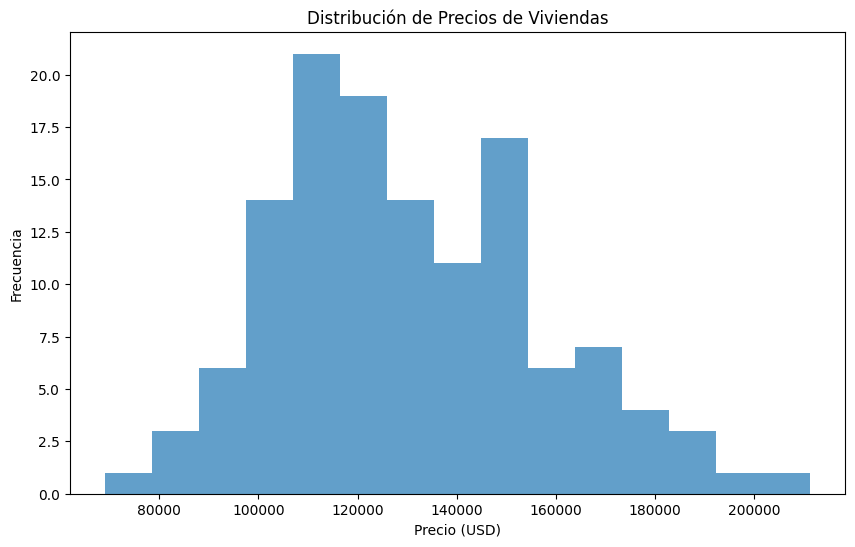

In [30]:
# Utilizamos matplot para realizar el histograma
plt.figure(figsize=(10, 6))
plt.hist(df_house_prices['Price'], bins=15, alpha=0.7)
plt.title('Distribución de Precios de Viviendas')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.show()

El histograma muestra distribución **ligeramente asimétrica a la izquierda** y la **mayor cantidad de casas** se encuentran **entre 9,000 USD y 15,000 USD**

### Diagrama de caja

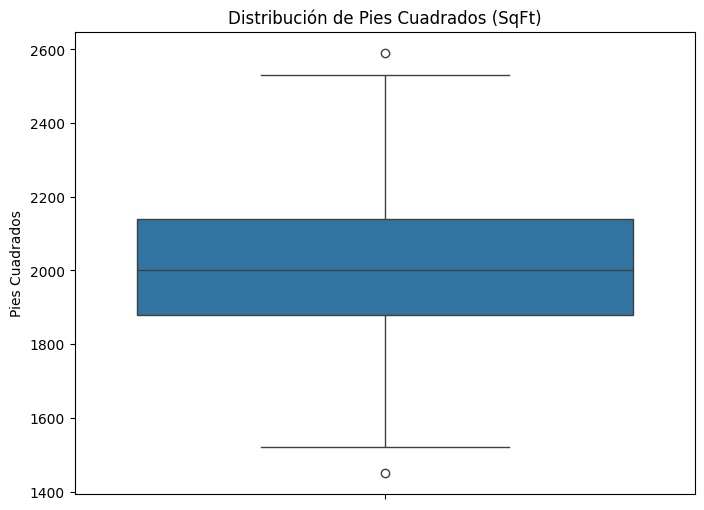

In [32]:
#Realizamos un Diagrama de caja para SqFt
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_house_prices['SqFt'])
plt.title('Distribución de Pies Cuadrados (SqFt)')
plt.ylabel('Pies Cuadrados')
plt.show()

La verdad no se leer este tipo de diagramas asi que todavia no puedo concluir nada.

### Graficos de dispersion

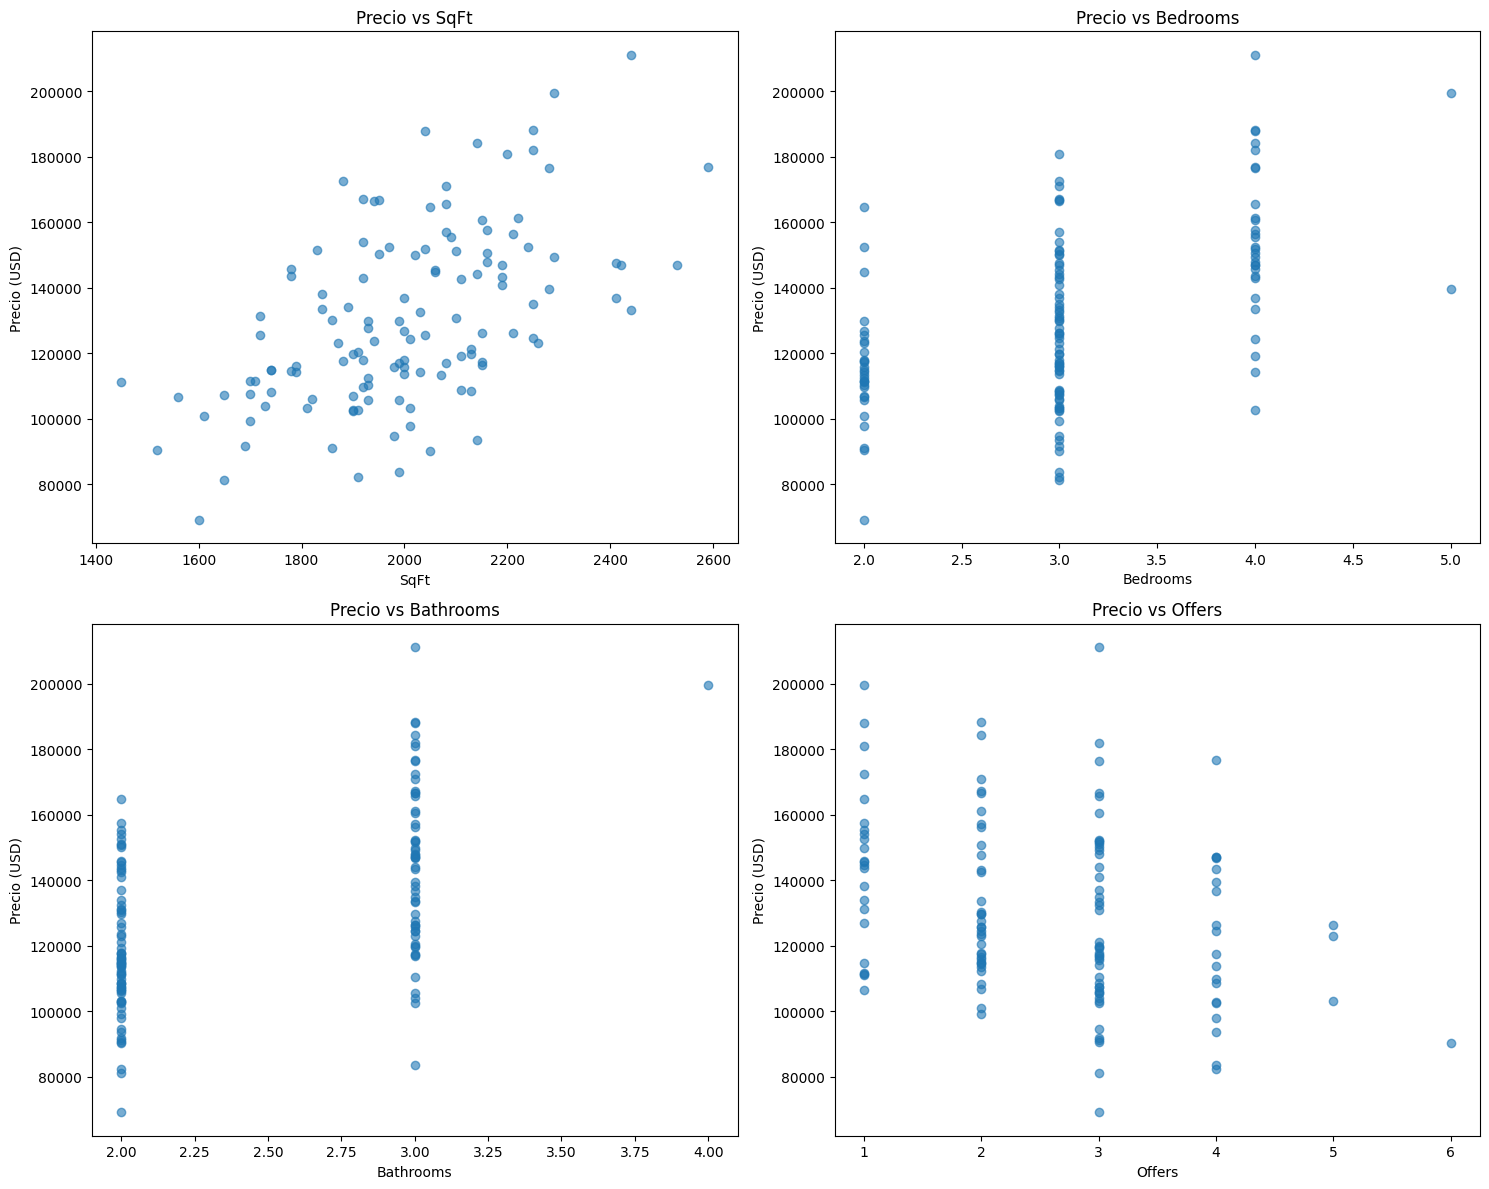

In [34]:
#utilizamos matplot (y deepseek para la optimizacion) para la creacion de los graficos
variables = ['SqFt', 'Bedrooms', 'Bathrooms', 'Offers']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, var in zip(axes.flatten(), variables):
    ax.scatter(df_house_prices[var], df_house_prices['Price'], alpha=0.6)
    ax.set_title(f'Precio vs {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()

## Reporte de los resultados
1. #### Clasificación de Variables:
    - **Cuantitativas Continuas**: Price, SqFt
    - **Cuantitativas Discretas**: Bedrooms, Bathrooms, Offers
    - **Cualitativas Nominales**: Neighborhood, Brick

2. #### Niveles de Medición:
    - **Razón**: Price, SqFt, Bedrooms, Bathrooms, Offers
    - **Nominal**: Neighborhood, Brick

3. #### Variable Dependiente: Price (precio de la vivienda)

4. Medidas de Tendencia Central:
    - Price: **Media** ≈ $154,725, Mediana ≈ $151,350, **Modas** = 103200, 105600, 117800, 125700, 129800

5. #### Medidas de Dispersión de Price:
    - **Pmean**        1.304273e+05
    - **50%**         1.259500e+05
    - **min**         6.910000e+04
    - **max**         2.112000e+05
    - **Varianza**    7.219308e+08
    - **std**         2.686877e+04
    - **Q1**          1.113250e+05
    - **Q3**          1.482500e+05d

6. #### Distribución de Precios:
    - El histograma muestra distribución **ligeramente asimétrica a la izquierda** y **la mayor cantidad de casas se encuentran entre 9,000 USD y 15,000 USD**
    - 
7. #### Análisis de SqFt:
    - N/A

8. Relaciones con el Precio:
    - **Correlación positiva** fuerte con SqFt (0.78)
    - **Correlación moderada** con Bathrooms (0.53)
    - **Correlación débil** con Bedrooms (0.37) y Offers (-0.32)

#### Conclusiones:
- El precio muestra mayor relación con los pies cuadrados construidos
- El número de baños tiene mayor impacto en el precio que los dormitorios
- La variable Brick (construcción en ladrillo) podría ser un factor diferenciador
- La mayor cantidad de casas se encuentran entre 9,000 USD y 15,000 USD